In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("vlr_stats.csv")
df

,URL,Mapa_Num,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,KAST,ADR,HS%,FK,FD,+/-_FK_FD
0,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,0,Haven,Darker,LOUD,Viper,1.12,256,18,16,6,2,70,166,30,2,1,1
1,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,0,Haven,cauanzin,LOUD,Sova,0.98,209,15,13,3,2,75,152,26,0,1,-1
2,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,0,Haven,Virtyy,LOUD,Yoru,0.70,178,14,16,4,-2,55,102,35,2,3,-1
3,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,0,Haven,pANcada,LOUD,Omen,0.67,145,11,13,1,-2,65,99,27,0,3,-3
4,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,0,Haven,lukxo,LOUD,Killjoy,0.65,192,13,16,3,-3,60,125,35,4,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,5,Haven,keiko,NRG,Viper,1.68,238,17,7,7,10,83,166,29,2,1,1
1066,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,5,Haven,mada,NRG,Neon,1.39,259,17,10,3,7,89,157,30,4,2,2
1067,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,5,Haven,brawk,NRG,Sova,1.17,196,12,10,5,2,83,122,21,3,1,2
1068,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,5,Haven,skuba,NRG,Killjoy,1.13,171,11,8,4,3,78,137,29,0,1,-1


In [3]:
df2 = pd.read_csv("vlr_placar.csv")
df2

,URL,Mapa,Time1,Mapas_T1,Score_T1,Time2,Mapas_T2,Score_T2,Vencedor
0,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,Haven,LOUD,NaN,7,Cloud9,NaN,13,Cloud9
1,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,Abyss,LOUD,NaN,11,Cloud9,NaN,13,Cloud9
2,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,AllMaps,LOUD,0.0,18,Cloud9,2.0,26,Cloud9
3,https://www.vlr.gg/596399/envy-vs-evil-geniuse...,Abyss,ENVY,NaN,9,Evil Geniuses,NaN,13,Evil Geniuses
4,https://www.vlr.gg/596399/envy-vs-evil-geniuse...,Corrode,ENVY,NaN,13,Evil Geniuses,NaN,10,ENVY
...,...,...,...,...,...,...,...,...,...
102,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,Corrode,MIBR,NaN,13,NRG,NaN,5,MIBR
103,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,Split,MIBR,NaN,10,NRG,NaN,13,NRG
104,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,Abyss,MIBR,NaN,4,NRG,NaN,13,NRG
105,https://www.vlr.gg/596427/mibr-vs-nrg-vct-2026...,Haven,MIBR,NaN,5,NRG,NaN,13,NRG


In [17]:
print(df.columns)
print('-------------------------------------------------------------------------------------')
print(df2.columns)



Index(['URL', 'Mapa_Num', 'Mapa', 'Jogador', 'Time', 'Agente', 'R', 'ACS', 'K',
       'D', 'A', '+/-', 'KAST', 'ADR', 'HS%', 'FK', 'FD', '+/-_FK_FD'],
      dtype='str')
-------------------------------------------------------------------------------------
Index(['URL', 'Mapa', 'Time1', 'Mapas_T1', 'Score_T1', 'Time2', 'Mapas_T2',
       'Score_T2', 'Vencedor'],
      dtype='str')


# ANÁLISE GRÁFICAS

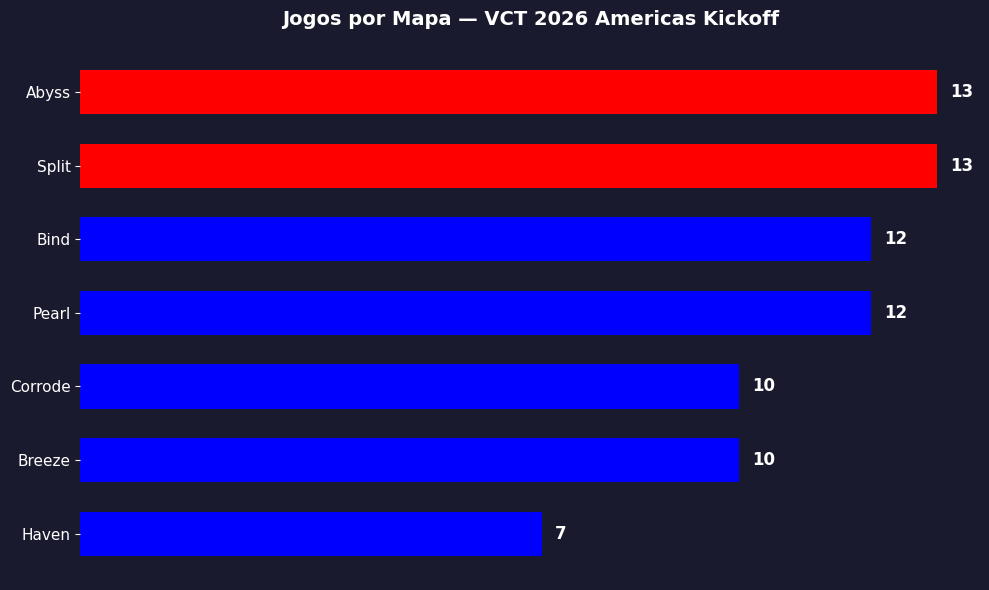

In [25]:
mapas = pd.Series({
    'AllMaps': 30,
    'Abyss': 13,
    'Split': 13,
    'Bind': 12,
    'Pearl': 12,
    'Corrode': 10,
    'Breeze': 10,
    'Haven': 7
})

mapas = mapas.drop('AllMaps')

fig, ax = plt.subplots(figsize=(10, 6))

cores = ['red' if v == mapas.max() else 'blue' for v in mapas.values]

bars = ax.barh(mapas.index[::-1], mapas.values[::-1], color=cores[::-1], edgecolor='none', height=0.6)

# Valor no final de cada barra
for bar, val in zip(bars, mapas.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=12, fontweight='bold', color='white')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Jogos por Mapa — VCT 2026 Americas Kickoff', color='white', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

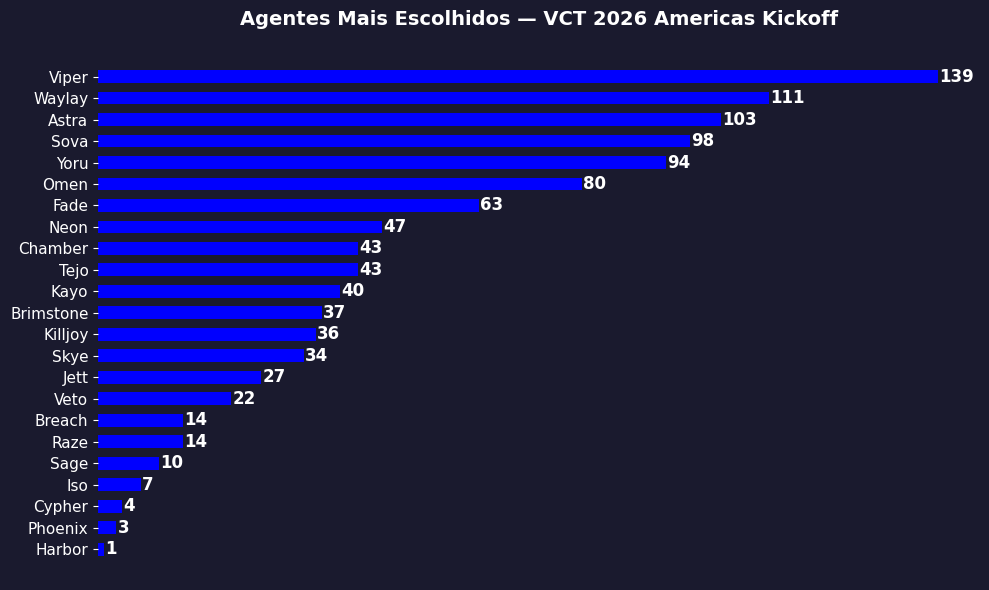

In [30]:
agentes = df['Agente'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

cores = ['blue']

bars = ax.barh(agentes.index[::-1], agentes.values[::-1], color=cores[::-1], edgecolor='none', height=0.6)

# Valor no final de cada barra
for bar, val in zip(bars, agentes.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=12, fontweight='bold', color='white')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Agentes Mais Escolhidos — VCT 2026 Americas Kickoff', color='white', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5605/1047371759.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', n + 2)


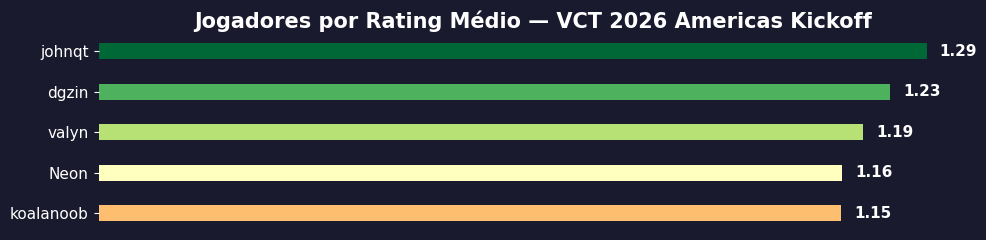

In [54]:
rating_por_jogador = (
    df[df['Mapa'] != 'AllMaps']
    .groupby('Jogador')['R'] # Mudar parametro para outras estatisticas
    .mean()
    .sort_values(ascending=False)
    .head(5)  #ajuste num de jogadores
)

n = len(rating_por_jogador)

fig, ax = plt.subplots(figsize=(10, n * 0.5))  

cmap = plt.cm.get_cmap('RdYlGn', n + 2)
cores = [cmap(i + 2) for i in range(n)]

bars = ax.barh(rating_por_jogador.index[::-1], rating_por_jogador.values[::-1],
               color=cores, edgecolor='none', height=0.4)  

for bar, val in zip(bars, rating_por_jogador.values[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Jogadores por Rating Médio — VCT 2026 Americas Kickoff',
             color='white', fontsize=15, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

In [73]:
df_allmap = df2[
    (df2['Mapa'] == 'AllMaps') &
    (df2['Mapas_T1'].notna()) &
    (df2['Mapas_T2'].notna())
].drop_duplicates(subset='URL', keep='last')

total_rounds = df_allmap['Score_T1'].sum() + df_allmap['Score_T2'].sum()
print(f"Total de rounds jogados: {total_rounds}")
print()

score_t1 = df_allmap.groupby('Time1')['Score_T1'].sum()
score_t2 = df_allmap.groupby('Time2')['Score_T2'].sum()

score_total = (score_t1
               .add(score_t2, fill_value=0)
               .sort_values(ascending=False)
               .astype(int))

print(score_total)

Total de rounds jogados: 1640

Time1
100 Thieves      231
Cloud9           177
NRG              174
MIBR             173
ENVY             149
FURIA            143
G2 Esports       143
Evil Geniuses    131
LEVIATÁN         107
Sentinels         89
KRÜ Esports       67
LOUD              56
dtype: int64


/tmp/ipykernel_5605/1193875653.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)


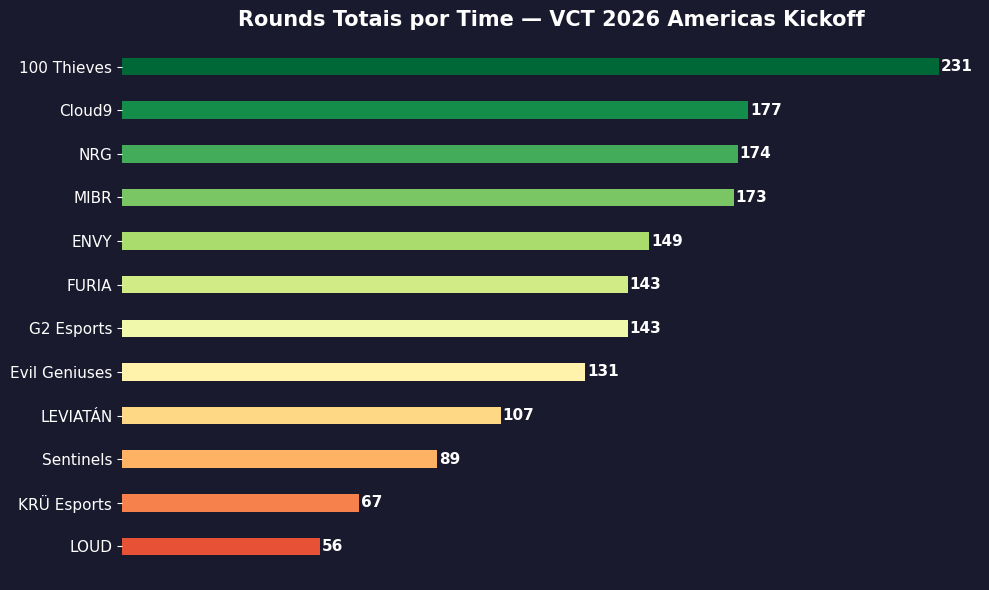

In [70]:
fig, ax = plt.subplots(figsize=(10, len(score_total) * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)
cores = [cmap(i + 2) for i in range(len(score_total))]

bars = ax.barh(score_total.index[::-1], score_total.values[::-1],
               color=cores, edgecolor='none', height=0.4)

for bar, val in zip(bars, score_total.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=11, fontweight='bold', color='white')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Rounds Totais por Time — VCT 2026 Americas Kickoff',
             color='white', fontsize=15, fontweight='bold', pad=5)

plt.subplots_adjust(top=0.97)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5605/3029302017.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)


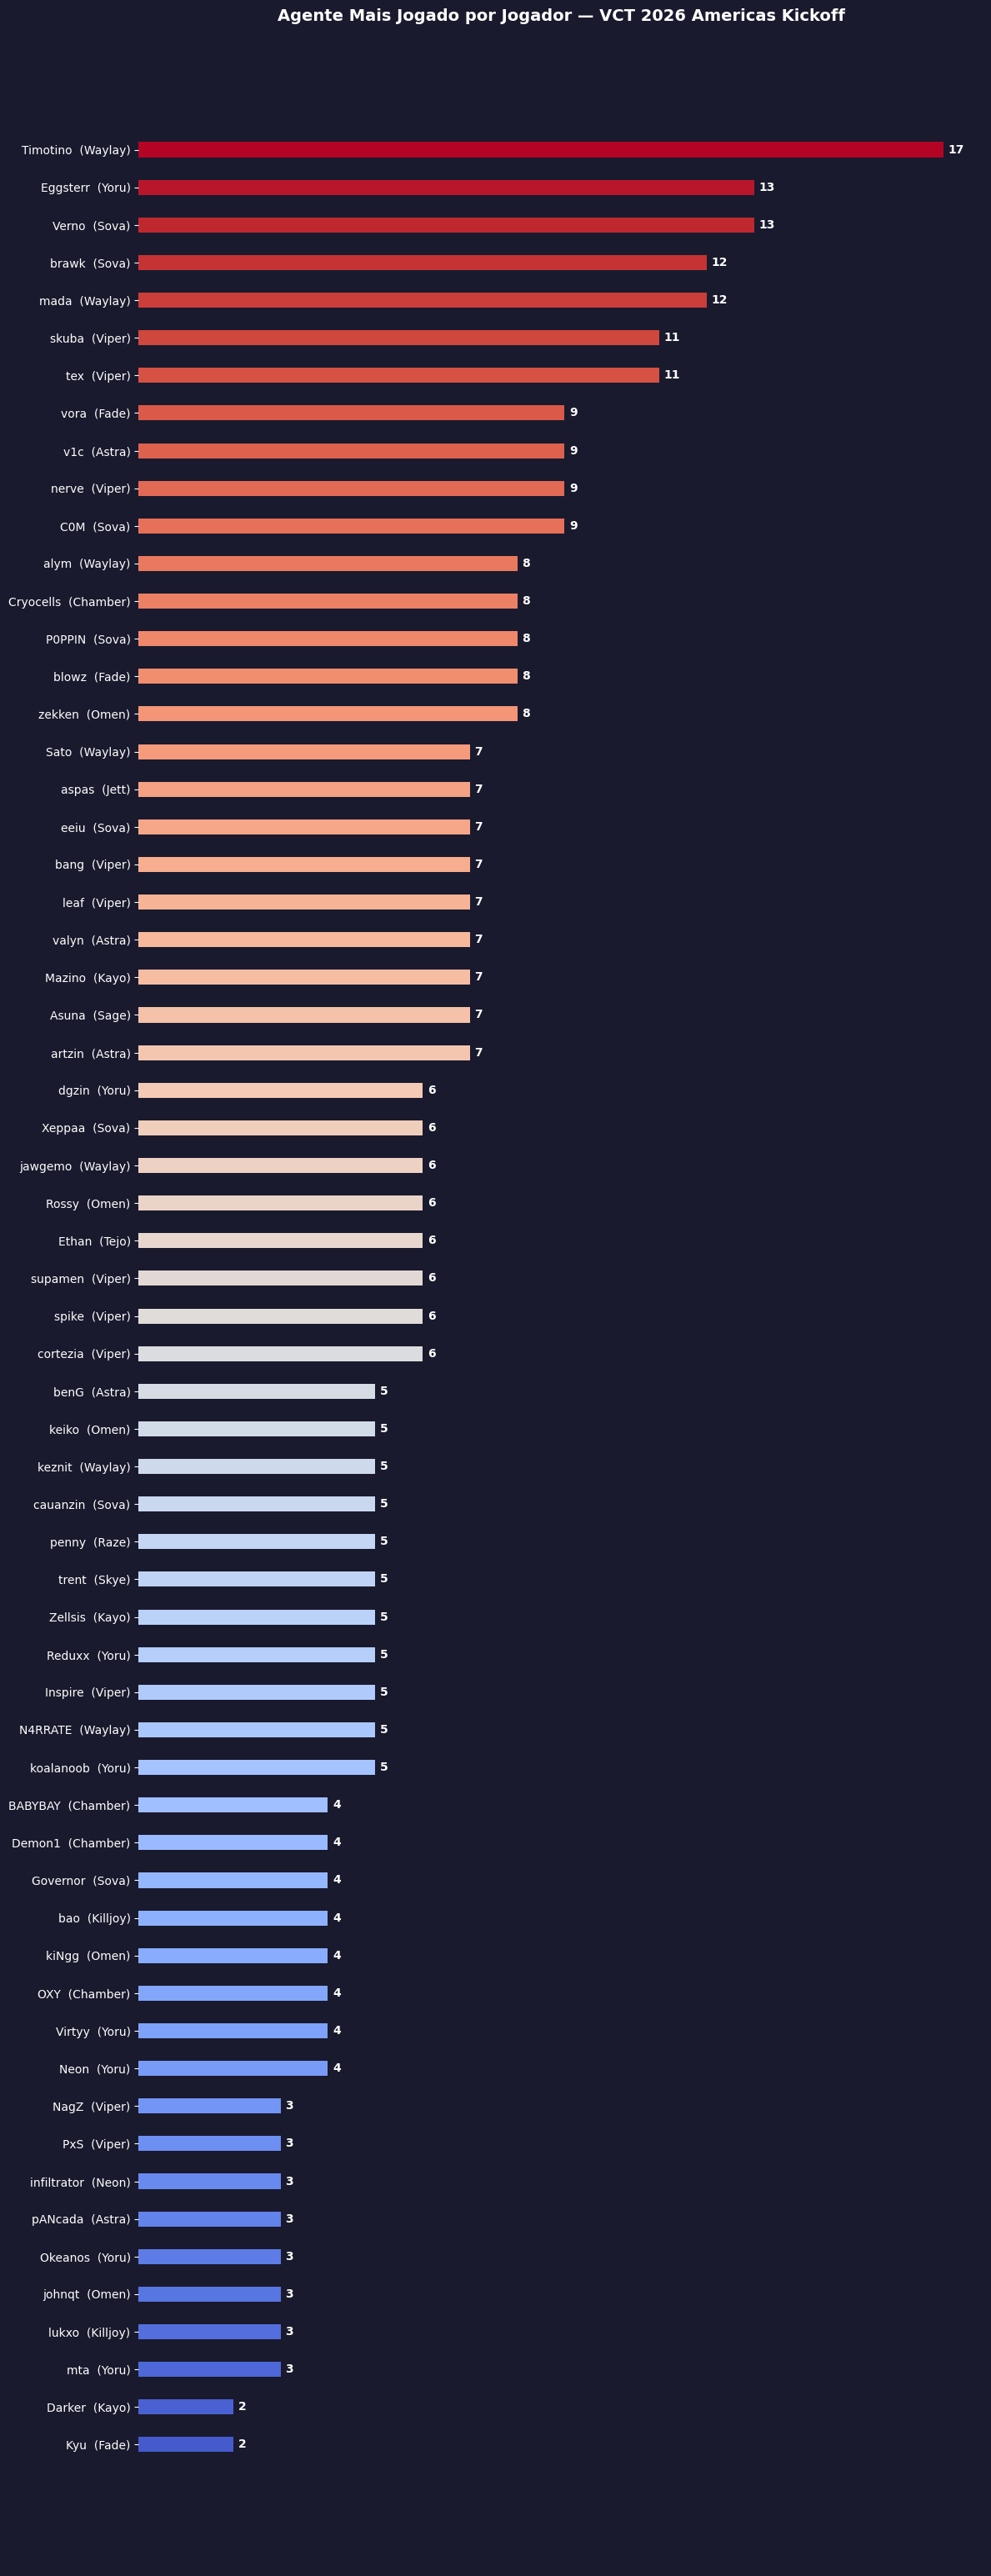

In [76]:
df_mapas = df[df['Mapa'] != 'AllMaps']

agente_jogador = (df_mapas.groupby(['Jogador', 'Agente'])
                  .size()
                  .reset_index(name='Partidas')
                  .sort_values('Partidas', ascending=False))

# Pega o agente mais jogado por jogador
top_agente = (agente_jogador
              .groupby('Jogador')
              .first()
              .reset_index()
              .sort_values('Partidas', ascending=False))

fig, ax = plt.subplots(figsize=(12, len(top_agente) * 0.5))

cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)
cores = [cmap(i + 2) for i in range(len(top_agente))]

bars = ax.barh(
    [f"{row.Jogador}  ({row.Agente})" for _, row in top_agente[::-1].iterrows()],
    top_agente['Partidas'].values[::-1],
    color=cores, edgecolor='none', height=0.4
)

for bar, val in zip(bars, top_agente['Partidas'].values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, fontweight='bold', color='white')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Agente Mais Jogado por Jogador — VCT 2026 Americas Kickoff',
             color='white', fontsize=14, fontweight='bold', pad=5)

plt.subplots_adjust(top=0.97)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6803/41146593.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)


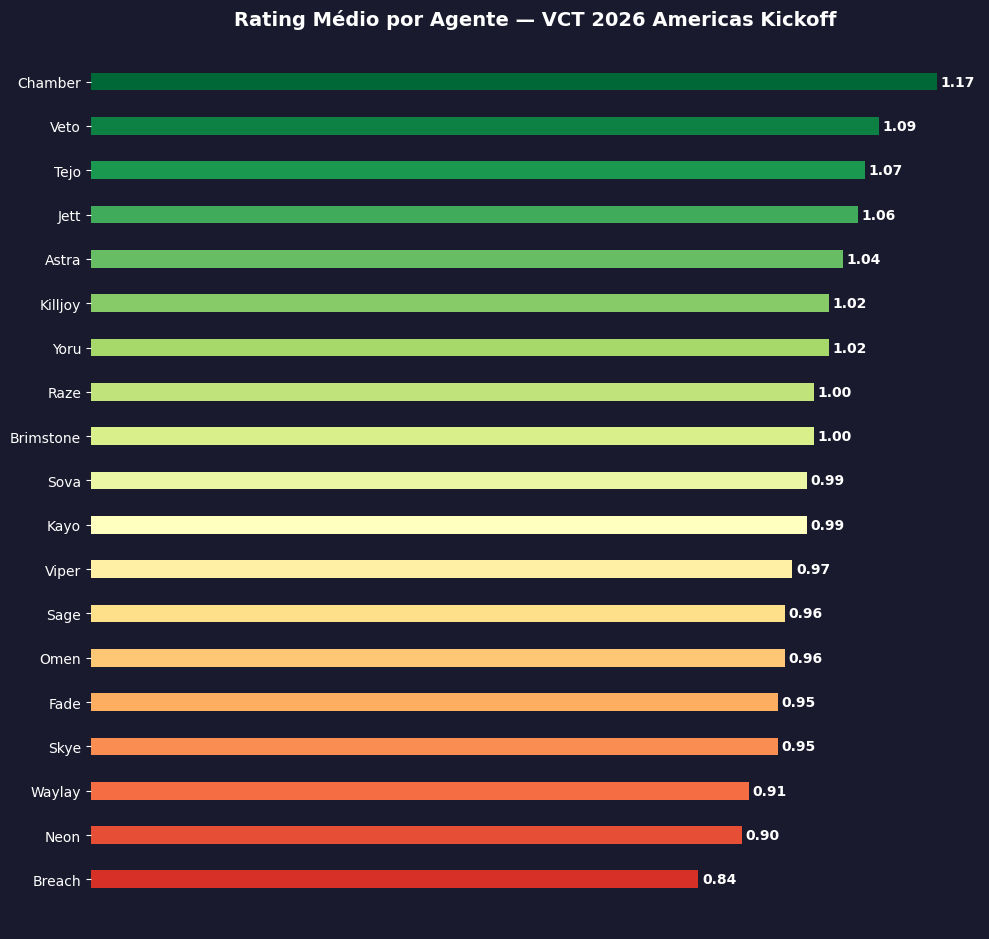

In [4]:
df_mapas = df[df['Mapa'] != 'AllMaps']

stats_agente = (df_mapas.groupby('Agente')
                .agg(
                    Partidas  = ('Agente', 'count'),
                    Rating    = ('R',    'mean'),
                    ACS       = ('ACS',  'mean'),
                    KD        = ('K',    'sum'),  # divide por deaths depois
                    Deaths    = ('D',    'sum'),
                    KAST      = ('KAST', 'mean'),
                    ADR       = ('ADR',  'mean'),
                )
                .assign(KD=lambda x: (x['KD'] / x['Deaths']).round(2))
                .query('Partidas >= 5')  # filtra agentes com poucos jogos
                .sort_values('Rating', ascending=False)
                .round(2))

# Gráfico — Rating médio por agente
fig, ax = plt.subplots(figsize=(10, len(stats_agente) * 0.5))
cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)
cores = [cmap(i + 2) for i in range(len(stats_agente))]
bars = ax.barh(stats_agente.index[::-1], stats_agente['Rating'].values[::-1],
               color=cores, edgecolor='none', height=0.4)
for bar, val in zip(bars, stats_agente['Rating'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=10); ax.spines[:].set_visible(False); ax.xaxis.set_visible(False)
ax.set_title('Rating Médio por Agente — VCT 2026 Americas Kickoff',
             color='white', fontsize=14, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6803/1620362008.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap('coolwarm', len(melhor_por_mapa) + 2)


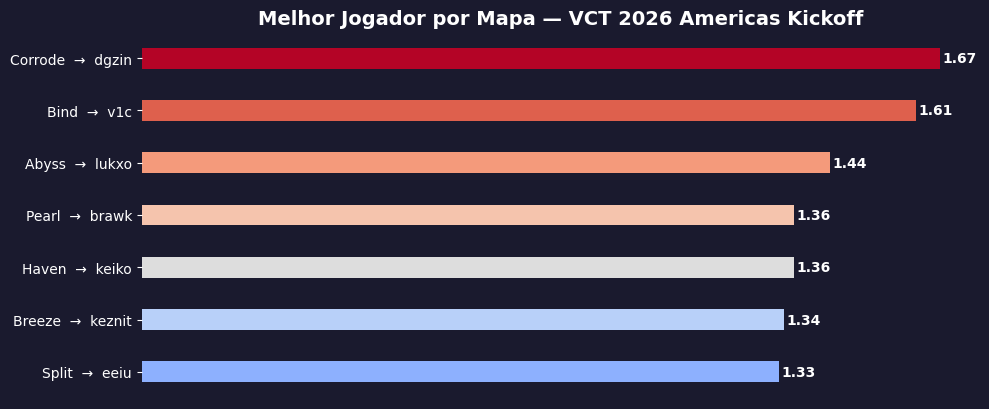

In [5]:
melhor_por_mapa = (df_mapas.groupby(['Mapa', 'Jogador'])
                   .agg(Rating=('R', 'mean'), Partidas=('R', 'count'))
                   .query('Partidas >= 2')
                   .reset_index()
                   .sort_values('Rating', ascending=False)
                   .groupby('Mapa')
                   .first()
                   .reset_index()
                   .sort_values('Rating', ascending=False))

fig, ax = plt.subplots(figsize=(10, len(melhor_por_mapa) * 0.6))
cmap2 = plt.cm.get_cmap('coolwarm', len(melhor_por_mapa) + 2)
cores2 = [cmap2(i + 2) for i in range(len(melhor_por_mapa))]
labels = [f"{row.Mapa}  →  {row.Jogador}" for _, row in melhor_por_mapa[::-1].iterrows()]
bars = ax.barh(labels, melhor_por_mapa['Rating'].values[::-1],
               color=cores2, edgecolor='none', height=0.4)
for bar, val in zip(bars, melhor_por_mapa['Rating'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=10); ax.spines[:].set_visible(False); ax.xaxis.set_visible(False)
ax.set_title('Melhor Jogador por Mapa — VCT 2026 Americas Kickoff',
             color='white', fontsize=14, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6803/1972762719.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = plt.cm.get_cmap('YlOrRd', len(kills_por_mapa) + 2)


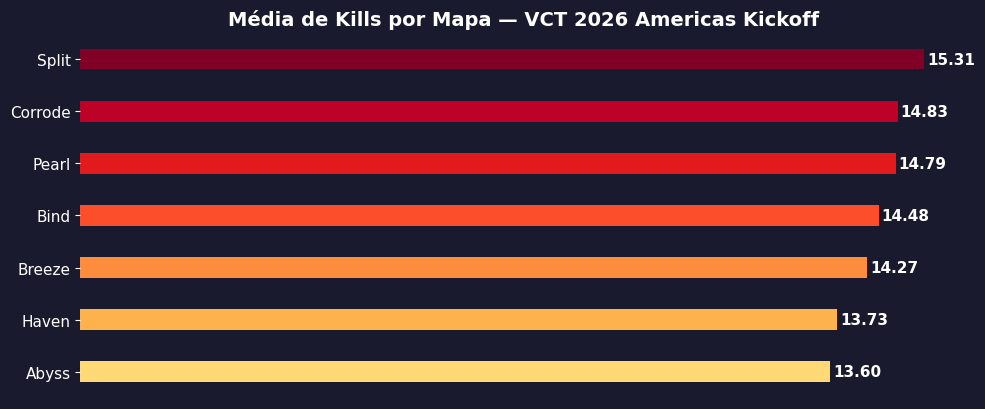

In [6]:
kills_por_mapa = (df_mapas.groupby('Mapa')['K']
                  .mean()
                  .sort_values(ascending=False)
                  .round(2))

fig, ax = plt.subplots(figsize=(10, len(kills_por_mapa) * 0.6))
cmap3 = plt.cm.get_cmap('YlOrRd', len(kills_por_mapa) + 2)
cores3 = [cmap3(i + 2) for i in range(len(kills_por_mapa))]
bars = ax.barh(kills_por_mapa.index[::-1], kills_por_mapa.values[::-1],
               color=cores3, edgecolor='none', height=0.4)
for bar, val in zip(bars, kills_por_mapa.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold', color='white')
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=11); ax.spines[:].set_visible(False); ax.xaxis.set_visible(False)
ax.set_title('Média de Kills por Mapa — VCT 2026 Americas Kickoff',
             color='white', fontsize=14, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

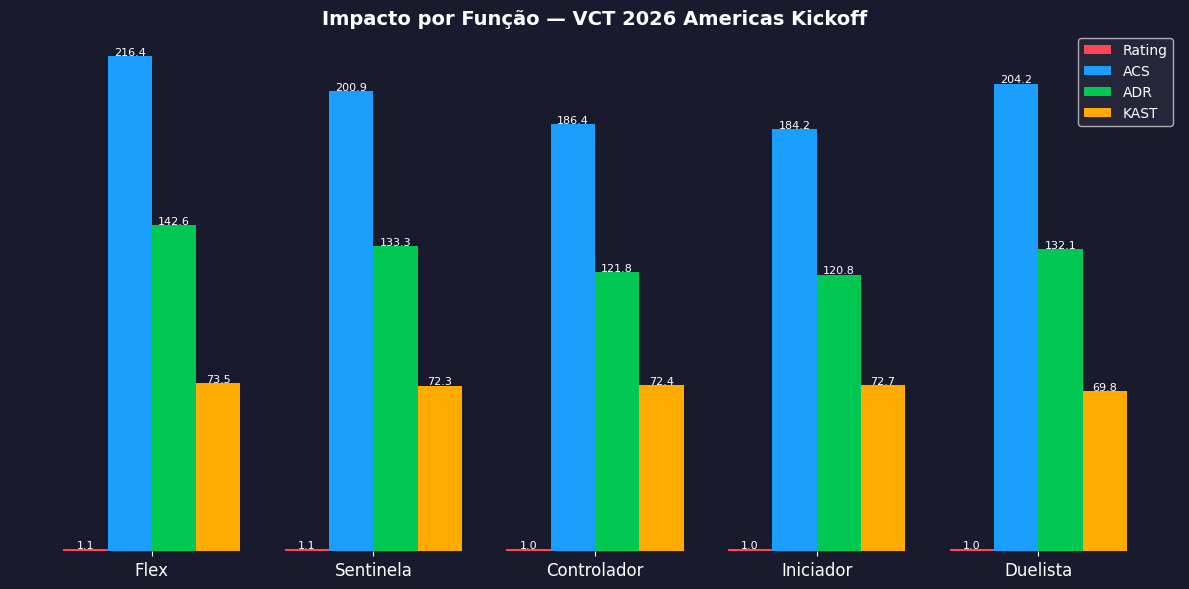

In [8]:
funcoes = {
    'Duelista':   ['Jett', 'Reyna', 'Raze', 'Yoru', 'Neon', 'Iso', 'Waylay'],
    'Iniciador':  ['Sova', 'Breach', 'Skye', 'Kayo', 'Fade', 'Gekko', 'Tejo'],
    'Controlador':['Brimstone', 'Viper', 'Omen', 'Astra', 'Harbor', 'Clove'],
    'Sentinela':  ['Killjoy', 'Cypher', 'Sage', 'Chamber', 'Deadlock', 'Vyse'],
}

agente_para_funcao = {
    agente: funcao
    for funcao, agentes in funcoes.items()
    for agente in agentes
}

df_func = df_mapas.copy()
df_func['Funcao'] = df_func['Agente'].map(agente_para_funcao).fillna('Flex')

impacto_funcao = (df_func.groupby('Funcao')
                  .agg(
                      Rating = ('R',    'mean'),
                      ACS    = ('ACS',  'mean'),
                      ADR    = ('ADR',  'mean'),
                      KAST   = ('KAST', 'mean'),
                      FK     = ('FK',   'mean'),
                  )
                  .round(2)
                  .sort_values('Rating', ascending=False))

metricas = ['Rating', 'ACS', 'ADR', 'KAST']
x        = range(len(impacto_funcao))
width    = 0.2
cores_func = ['#ff4655', '#1a9fff', '#00c853', '#ffab00']

fig, ax = plt.subplots(figsize=(12, 6))
for j, (metrica, cor) in enumerate(zip(metricas, cores_func)):
    offset = [i + j * width for i in x]
    bars   = ax.bar(offset, impacto_funcao[metrica], width=width,
                    label=metrica, color=cor, edgecolor='none')
    for bar, val in zip(bars, impacto_funcao[metrica]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=8, color='white')

ax.set_xticks([i + width * 1.5 for i in x])
ax.set_xticklabels(impacto_funcao.index, color='white', fontsize=12)
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white'); ax.spines[:].set_visible(False); ax.yaxis.set_visible(False)
ax.legend(facecolor='#2a2a3e', labelcolor='white', fontsize=10, loc='upper right')
ax.set_title('Impacto por Função — VCT 2026 Americas Kickoff',
             color='white', fontsize=14, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()